In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the Dataset
df = pd.read_csv("/content/drive/MyDrive/house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
# Check Dataset
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [4]:
# Handle Missing Values
df.isnull().sum()

# Drop missing values
df = df.dropna()

In [5]:
# Remove Duplicate Records
df.duplicated().sum()
df = df.drop_duplicates()

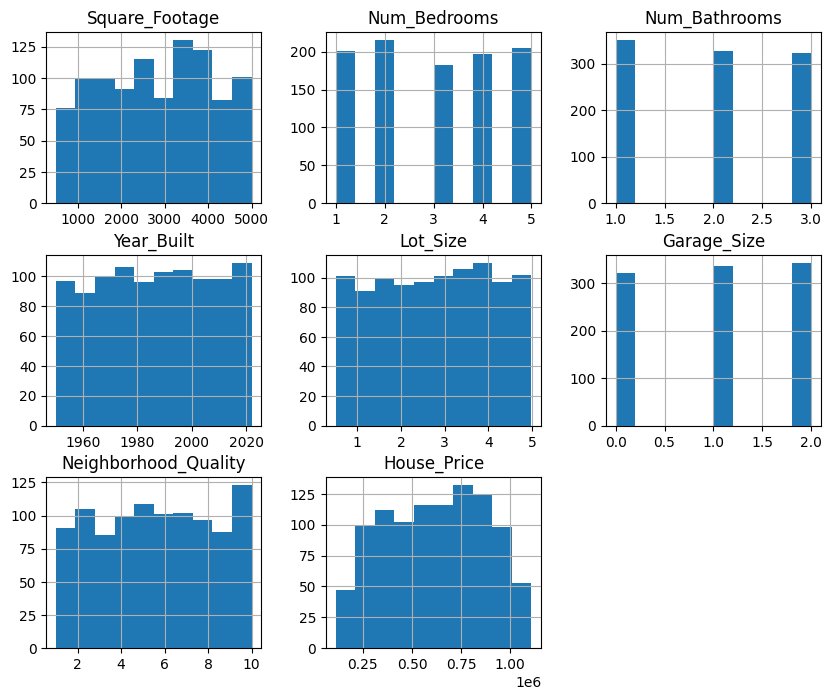

In [6]:
# Perform Univariate Analysis
df.hist(figsize=(10,8))
plt.show()

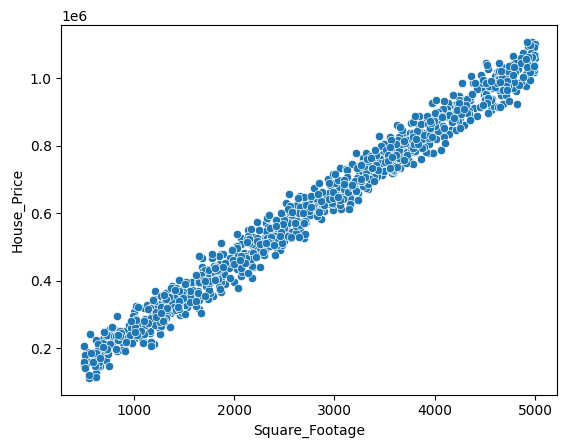

In [7]:
# Perform Bivariate Analysis
sns.scatterplot(x="Square_Footage", y="House_Price", data=df)
plt.show()

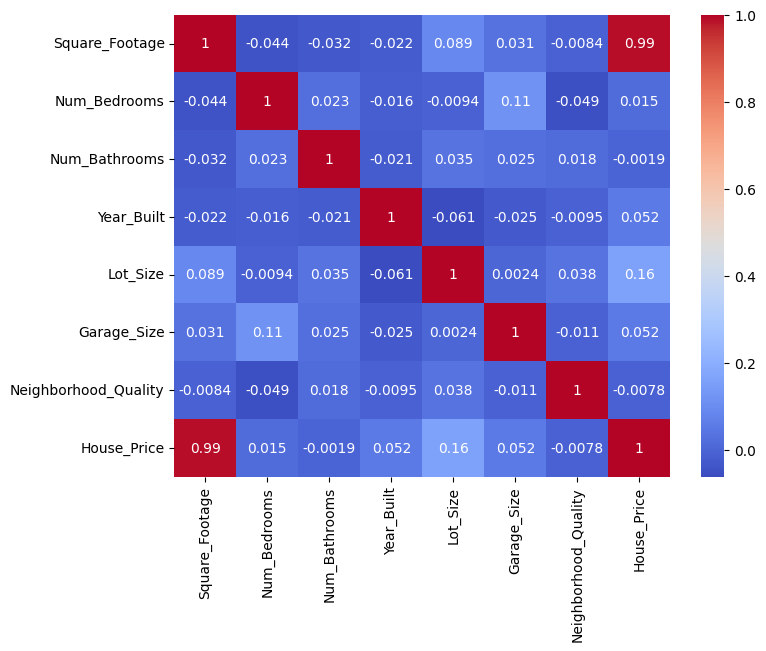

In [8]:
# Generate Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

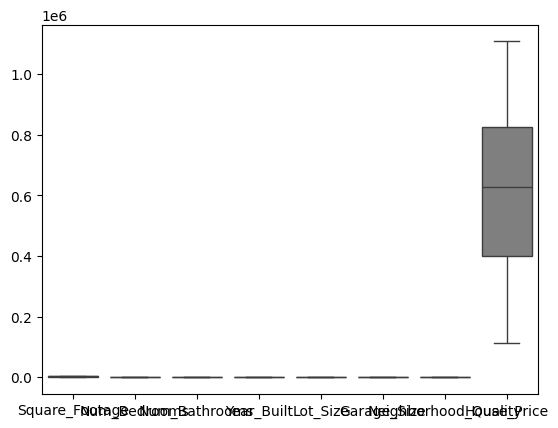

In [9]:
# Detect and Handle Outliers
sns.boxplot(data=df)
plt.show()

In [10]:
# Apply Encoding (if categorical variables exist)
df = pd.get_dummies(df, drop_first=True)

In [11]:
# Apply Log Transformation
df["House_Price"] = np.log(df["House_Price"])

In [12]:
# Separate Features and Target Variable
X = df.drop("House_Price", axis=1)
y = df["House_Price"]
plt.show()

In [13]:
# Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Apply Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train Regression Models
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# KNN regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
# Evaluate Models Using
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [ ]:
# adjusted R2 score
def adjusted_r2(r2, X):
    n = X.shape[0]   # number of samples
    p = X.shape[1]   # number of features

    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return adj_r2

# MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Evaluate KNN
def evaluate_full(y_test, y_pred, X_test):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    adj_r2 = adjusted_r2(r2, X_test)
    mape_val = mape(y_test, y_pred)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("Adjusted R2:", adj_r2)
    print("MAPE:", mape_val)

In [ ]:
# Linear Regression Evalutation
evaluate_full(y_test, y_pred_lr, X_test)

MAE: 0.09078292767761202
MSE: 0.012923132230239545
RMSE: 0.11367995527022143
R2 Score: 0.9462493474741257
Adjusted R2: 0.9442896882674532
MAPE: 0.695987033882357


In [ ]:
# KNN Evalutation
evaluate_full(y_test, y_pred_knn, X_test)

MAE: 0.13352458657348393
MSE: 0.03275242370493434
RMSE: 0.18097630702645676
R2 Score: 0.8637741907627683
Adjusted R2: 0.8588076248009943
MAPE: 1.0316078365784032
